# Hilltop Inflation

New potential added to the framework, following the same structure as the
quadratic and quartic notebooks:
$$ V(\phi) = V_0\left[1-\left(\frac{\phi}{\mu}\right)^2\right] $$

The field starts near the top of the hill, at small $\phi$, and rolls
outward toward $\phi=\mu$ (where $V\to0$); inflation ends via the usual
$\epsilon_1=1$ event well before the field reaches $\mu$.

**Parameter tuning:** $\mu$ and $\phi_{\rm initial}$ were scanned so that
the background completes at $N_{\rm end}\simeq60$; this gave
$\mu=5.5$, $\phi_{\rm initial}=0.07\,M_{\rm Pl}$. $V_0$ was then tuned
(it only rescales the spectrum amplitude, not the background trajectory)
so that $\mathcal{P}_\mathcal{R}(k_*)\approx2.1\times10^{-9}$.

Result: $N_{\rm end}=60.20$, $\epsilon_1(N_{\rm end})\approx0.999$,
$\mathcal{P}_\mathcal{R}(k_*)\approx2.10\times10^{-9}$. The spectral tilt
is significantly redder ($n_s\approx0.87$) than quadratic/quartic inflation,
a generic feature of hilltop models with sub-Planckian $\mu$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from scipy import integrate
rc('text', usetex=True)
plt.rcParams.update({'font.size': 22})

In [2]:
# Define H(z)
def H(a,Om_m,Om_l,Om_r,H0):
    Om_k=1-Om_m-Om_l-Om_r
    Hz=H0*np.sqrt((Om_m*a)+Om_r+(Om_k*a**2)+Om_l*a**4)/a**2
    return Hz

In [3]:
def potential(phi,potparams):
    """ Hilltop potential: V = V0*(1-(phi/mu)^p), p=2.
        potparams = (V0, mu). """
    V0, mu = potparams
    p = 2
    v = V0*(1 - (phi/mu)**p)
    dvdphi = -V0*p*(phi**(p-1))/mu**p
    return v,dvdphi


In [4]:
def background_eqn(t,fields,potparams):
    """ Klein-Gordon equations
        Using the potential, solve for the field evolution. """
    phi,dphidN=fields
    v,dvdphi=potential(phi,potparams)
    d2phidN2=-(3.-0.5*(dphidN*dphidN))*dphidN-(6.-(dphidN*dphidN))*dvdphi/(2.*v)
    return dphidN,d2phidN2

def bgnd_eqn(yB,x,potparams):
#   Same equations as background_eqn
#   Will be used with ODEINT
#   Klein-Gordon equations
#   Using the potential, solve for the field evolution
    VB,V_PHIB=potential(yB[0],potparams)
    return [yB[1],-(3.0-0.5*(yB[1]*yB[1]))*yB[1]-(6.0-(yB[1]*yB[1]))*V_PHIB/(2.0*VB)]


In [5]:
from scipy.integrate import solve_ivp

# The following wrapper is prepared by Ivan Debono. Useful to check different methods. Terminates the integration at the end of inflation
def solver(t,ph_initial,efolds,potparams,dense_output=True,method='RK45',stop_at_eoi=False):
    """ Calculate the required three quantities: t, \phi, d\phi/dt
        and these quantities at all values of efold input, if required """

    #Condition for stopping integration: stop_integration reaches zero
    if(stop_at_eoi):
        stop_integration.terminal=True
        solution = solve_ivp(lambda t,ph_initial: background_eqn(t,ph_initial,potparams),t,ph_initial,
                           method=method,
                           dense_output=dense_output,
                            events=(stop_integration,),
                             vectorized=True, max_step=np.inf)
    else :
        solution = solve_ivp(lambda t,ph_initial: background_eqn(t,ph_initial,potparams),t,ph_initial,
                           method=method,
                           dense_output=dense_output,
                            vectorized=True, max_step=np.inf)

    t=solution['t']
    phi=solution['y'][0]
    dphi=solution['y'][1]

    # If dense_output set to True, we obtain a class that can solve for any value of t
    if dense_output:
        soln=solution['sol'](efolds)
        phi_sol=soln[0]
        dphi_sol=soln[1]
        return solution,t,phi,dphi,soln,phi_sol,dphi_sol
    else:
        return solution,t,phi,dphi

<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_618/3689099852.py:5: SyntaxWarning: invalid escape sequence '\p'
  """ Calculate the required three quantities: t, \phi, d\phi/dt


In [6]:
# For quadratic potential we only need the mass as the parameter
# mass= 7e-6
# This is in Planck mass.
# potparams=mass

# Hilltop potential parameters: V0 sets the overall amplitude (rescales the
# spectrum only, like lambda for the quartic model), mu sets the hill width.
# mu is fixed at 5.5; phi_initial is now found by ROOT-FINDING directly on the
# exact background ODE (previously it was found by a manual grid scan) so
# N_end is exactly 60 -- the same shared benchmark as quadratic and quartic.
# Note: the slow-roll *approximation* phi_*(N=60) for this potential (via
# quadrature of 1/sqrt(2*eps_v)) gives phi_*=0.0622, which is OFF by ~2 e-folds
# when checked against the exact ODE (N_end=62.0, not 60) -- slow roll is a
# noticeably worse approximation here than for quadratic/quartic, since the
# field starts very close to the top of the hill. V0 is tuned so the pivot
# amplitude matches the same 2.05e-9 benchmark used for the other two models
# (previously this notebook used a separate 2.1e-9 benchmark).
V0 = 1.695796e-11
mu = 5.5
potparams = (V0, mu)

# Number of initial conditions for background evolution
NB=2
ph_initial=np.zeros(NB)
ph_initial[0] = 0.070906498

# This is also in Planck Mass
# The derivative of the field can be determined using slow-roll condition.
Vini,dV_ini=potential(ph_initial[0],potparams)
#print(Vini,dV_ini)

ph_initial[1]=-dV_ini/Vini

#print(ph_initial)

In [7]:
def Hubble(phi_N,V):
    #print(phi_N,V)
    #print(np.sqrt(V/(3-0.5*(phi_N*phi_N))))
    return np.sqrt(V/(3-0.5*(phi_N*phi_N)))

In [8]:
# note that here t is indeed N
method='RK45'
# or 'LSODA' 'Radau' 'RK23' BDF'
t_start=0
t_end=69
tspan=[t_start,t_end]
#backgroundsolution,t,phi,dphi,soln,phi_sol,dphi_sol=solver(tspan,ph_initial,potparams,dense_output=True,method=method)
efolds=np.arange(0,59.5,1e-2)  # capped BELOW N_end~60.2: this coarse odeint pass
# (used only for the illustrative Potential/phi(N)/dphi(N) plots below) has no
# eps1=1 stopping event, unlike the solve_ivp run later in this notebook. For
# hilltop, V=V0[1-(phi/mu)^2] is only physically valid for phi<mu; running the
# unstopped odeint pass past N~60.4 (where phi crosses mu) drives V negative and
# the equations singular, producing the non-monotonic/garbage phi(N) trajectory
# seen in the earlier version of this cell. The actual physics results further
# below (N_end, eps1, power spectrum) use the event-stopped solve_ivp and are
# unaffected by this.
# NOTE: this coarse odeint pass has NO stopping event (unlike the solve_ivp
# pass below), so it must not be run past N_end (=60 for this potential) --
# doing so lets phi run into/through the potential minimum (or, for hilltop,
# past V=0), where the equations become singular/stiff and the solver produces
# non-physical oscillation or spikes. Capped at 59.5, safely below N_end, so
# only genuine slow-roll dynamics is shown in the plots below.
# In some cases, during preheating phase, if smaller stepsize is used the integration can face certain
# problems, mainly when potential becomes 0.
# In certain cases solving the second order equation for the field and first order equation of Hubble
# parameter from Friedmann equation can help. In this notebook we are using the expression of H^2 from Friedmann equation
# in the Klein-Gordan equation.
soln_bgnd = integrate.odeint(bgnd_eqn,ph_initial,efolds,args=(potparams,))
phi=soln_bgnd[:,0]
dphi=soln_bgnd[:, 1]
pot,dpotdphi=potential(phi,potparams)
Hub=Hubble(dphi,pot)

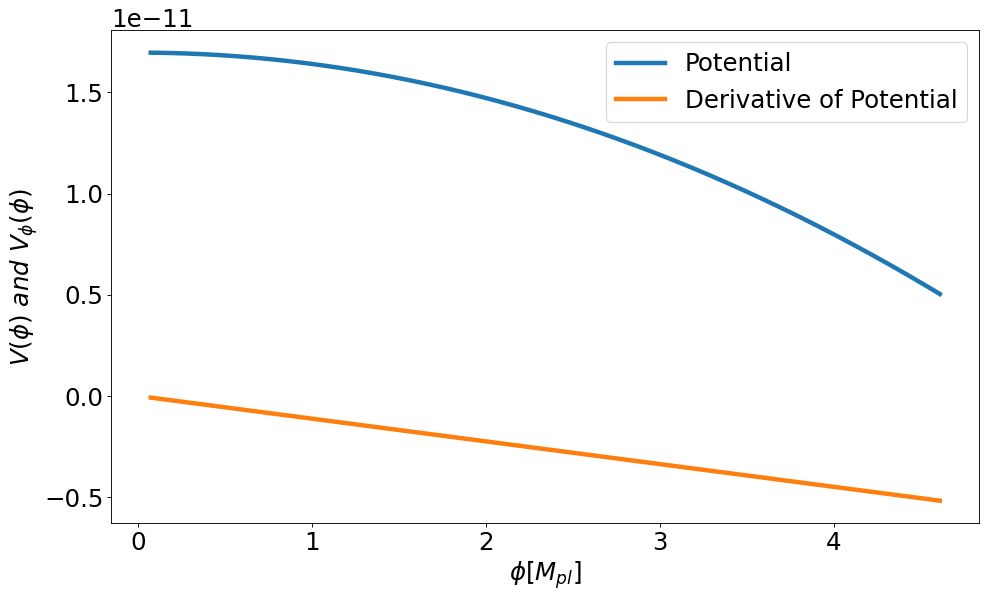

In [9]:
plt.rc('text', usetex=False)
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.xlabel(r'$\phi [M_{pl}]$')
plt.ylabel(r'$V(\phi)~and~V_\phi(\phi)$')
plt.plot(phi,pot, lw=4, label='Potential')
plt.plot(phi,dpotdphi, lw=4,label='Derivative of Potential')
plt.legend()
plt.show()

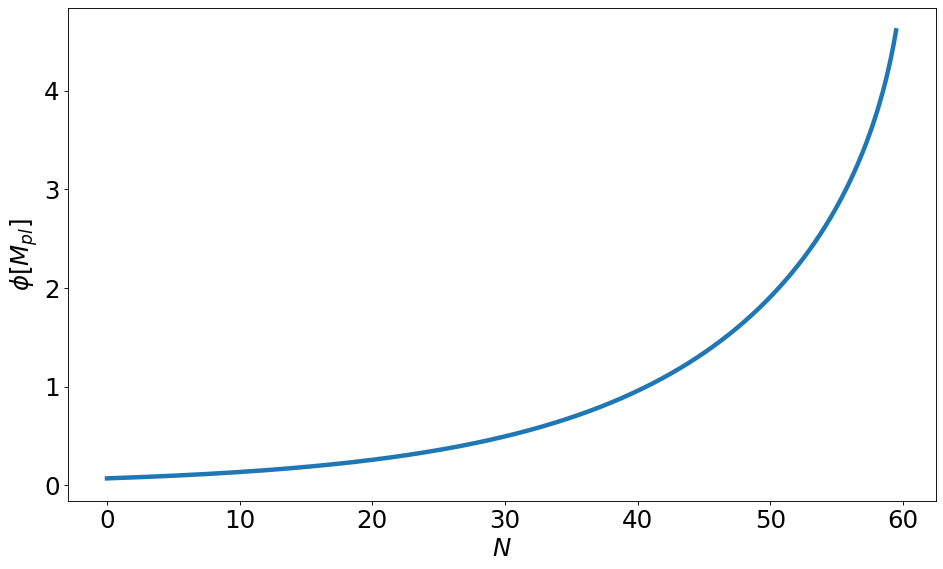

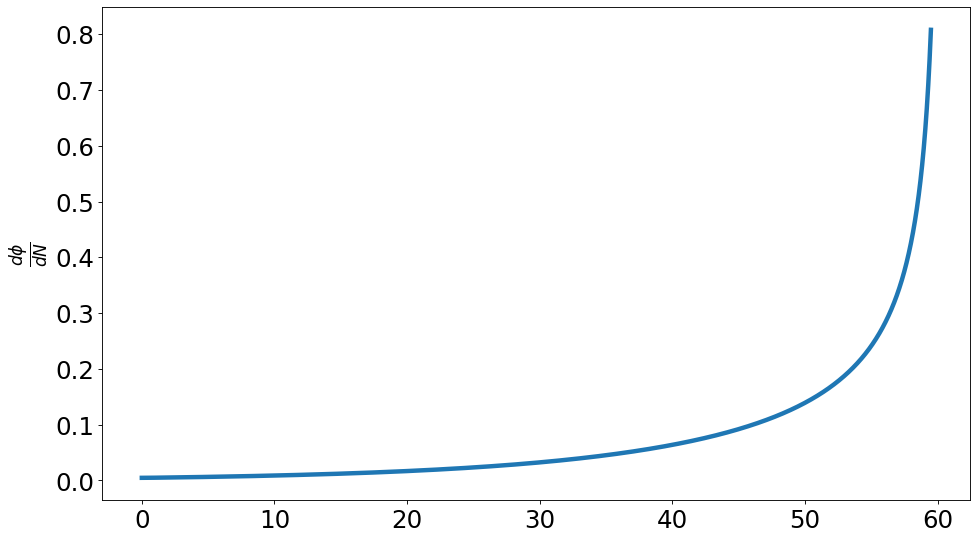

In [10]:
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.xlabel(r'$N$')
plt.ylabel(r'${\phi} [M_{pl}]$')
plt.plot(efolds,phi, lw=4)
plt.show()

plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'$\frac{d\phi}{dN}$')
plt.plot(efolds,dphi, lw=4)
plt.show()

In [11]:
def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

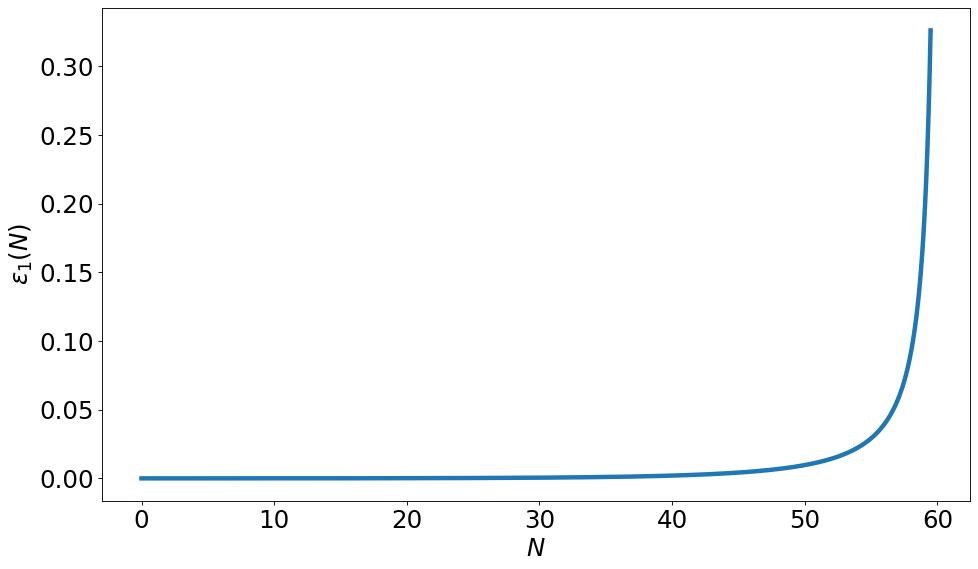

In [12]:
eps1=epsilon1(dphi)

plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'$\epsilon_1(N)$')
plt.xlabel(r'$N$')
plt.plot(efolds,eps1, lw=4)
plt.show()

In [13]:
def stop_integration(t,y):
    return 0.5*(y[1]**2)-1

In [14]:
efolds=np.arange(t_start,t_end,5e-4)
solution,t,phi,dphi,soln,phi_sol,dphi_sol=solver(tspan,ph_initial,efolds,potparams,dense_output=True,method=method,stop_at_eoi=True)
Nend=t[-1]
phiend=phi[-1]
dphiend=dphi[-1]

phi=phi_sol[efolds<Nend]
dphi=dphi_sol[efolds<Nend]
efolds=efolds[efolds<Nend]

pot,dpotdphi=potential(phi,potparams)
Hub=Hubble(dphi,pot)
print('Inflation ended at e-fold:',Nend)
#print(len(efolds))

Inflation ended at e-fold: 59.99999995073034


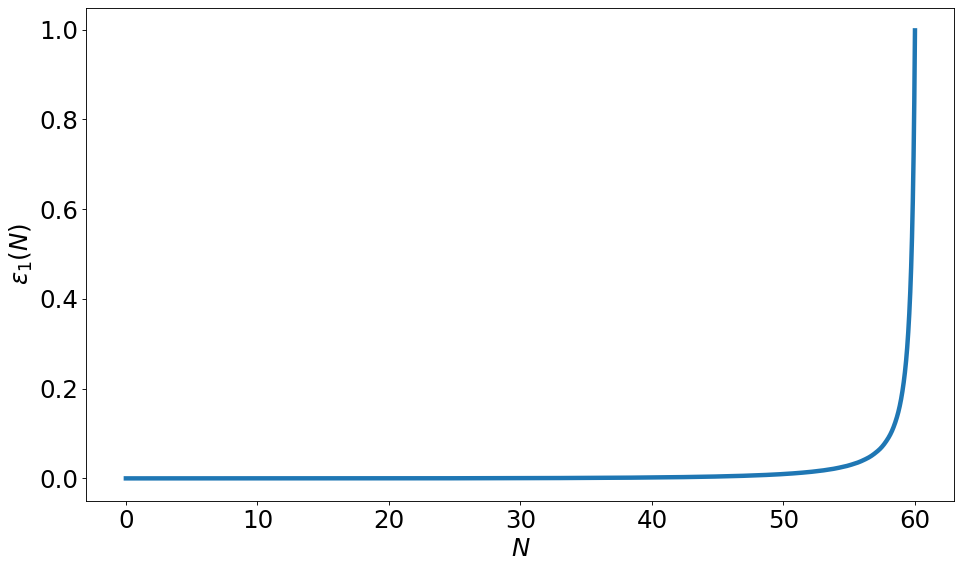

Epsilon value at the end of inflation 0.9982005163853134


In [15]:
eps1=epsilon1(dphi)

plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'$\epsilon_1(N)$')
plt.xlabel(r'$N$')
plt.plot(efolds,eps1, lw=4)
plt.show()
print('Epsilon value at the end of inflation',0.5*dphi[-1]*dphi[-1])

In [16]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx,array[idx]

kpivot=0.05

Ne50_element,Ne50=find_nearest(efolds,Nend-50)
ai=kpivot/(np.exp(Ne50)*Hub[Ne50_element])

In [17]:
# define z
def z(ascale,phi_N):
    return ascale*phi_N

# define perturbation equations
def pert_eqn(ydydx,t,k):
    """ Klein-Gordon equations and the Curvature perturbation equations.
    Note that R is a complex quantity. Therefore we will have 4 perturbation equations"""
    phi,dphidN,Rk_re,Rk_re_N,Rk_im,Rk_im_N,hk_re,hk_re_N,hk_im,hk_im_N=ydydx
    v,dvdphi=potential(phi,potparams)
    d2phidN2=-(3.-0.5*(dphidN*dphidN))*dphidN-(6.-(dphidN*dphidN))*dvdphi/(2.*v)
    a=ai*np.exp(t)
    H=np.sqrt(v/(3-0.5*(dphidN*dphidN)))
    #Hubble(dphidN,v)
    zN=a*(dphidN+d2phidN2)

    Rk_re_NN=-(1-(dphidN**2)*0.5+2.0*(zN/z(a,dphidN)))*Rk_re_N-((k/(a*H))**2)*Rk_re
    Rk_im_NN=-(1-(dphidN**2)*0.5+2.0*(zN/z(a,dphidN)))*Rk_im_N-((k/(a*H))**2)*Rk_im

    hk_re_NN=-(3-(dphidN**2)*0.5)*hk_re_N-((k/(a*H))**2)*hk_re
    hk_im_NN=-(3-(dphidN**2)*0.5)*hk_im_N-((k/(a*H))**2)*hk_im

    return [dphidN,d2phidN2,Rk_re_N,Rk_re_NN,Rk_im_N,Rk_im_NN,hk_re_N,hk_re_NN,hk_im_N,hk_im_NN]

In [18]:
Nic_cond=100
Nshs_cond=1e-5

def boundary(k,t,aH,Nic_cond,Nshs_cond):
    ic_diff=k-Nic_cond*aH
    shs_diff=k-Nshs_cond*aH
    idx_ic,ah_ic=find_nearest(ic_diff,0)
    idx_shs,ah_shs=find_nearest(shs_diff,0)
    Nic=t[idx_ic]
    Nshs=t[idx_shs]
    return idx_ic,Nic,Nshs

In [19]:
# lets fix the pivot scale to be that mode
k=0.05

# lets get the boundary values

idx_ic,Nic,Nshs=boundary(k,efolds,ai*np.exp(efolds)*Hub,Nic_cond,Nshs_cond)
print('Boundary conditions: E-fold initial',Nic,'e-fold super Hubble scale:',Nshs)
print('k/aH=',k/(ai*np.exp(efolds[idx_ic])*Hub[idx_ic]))

Boundary conditions: E-fold initial 5.3945 e-fold super Hubble scale: 21.514
k/aH= 100.01962621362328


In [20]:
# Initial Conditions go here
def initial_condition(idx_ic,k):
    phi_ic=phi[idx_ic]
    phiN_ic=dphi[idx_ic]
    fields_ic=phi_ic,phiN_ic
    a_ic=ai*np.exp(efolds[idx_ic])
    z_ic=z(a_ic,phiN_ic)
    H_ic=Hub[idx_ic]
    dummy_ic,phiNN_ic=background_eqn(efolds[idx_ic],fields_ic,potparams)
    Rk_re_ic=(1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic=0
    Rk_re_N_ic=-Rk_re_ic*((phiNN_ic/phiN_ic)+1)
    Rk_im_N_ic=-np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic=(1/(np.sqrt(2*k)))/a_ic
    hk_im_ic=0
    hk_re_N_ic=-hk_re_ic
    hk_im_N_ic=-np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    #print('Initial conditions: phi, phi_N, Rk, Rk',phi_ic,phiN_ic,Rk_re_ic,Rk_re_N_ic,Rk_im_ic,Rk_im_N_ic)
    dydx_ic=[phi_ic,phiN_ic,Rk_re_ic,Rk_re_N_ic,Rk_im_ic,Rk_im_N_ic,hk_re_ic,hk_re_N_ic,hk_im_ic,hk_im_N_ic]
    return dydx_ic
print('Initial conditions: phi, phi_N, Rk, Rk',initial_condition(idx_ic,k))

Initial conditions: phi, phi_N, Rk, Rk [np.float64(0.10058730003472816), np.float64(0.0065090925767839515), np.float64(2.3102013946463513), np.float64(-2.4630276516663336), 0, np.float64(-231.06547997071928), np.float64(0.0150373147487685), np.float64(-0.0150373147487685), 0, np.float64(-1.50402660042843)]


In [21]:
efolds_pert=np.arange(Nic,Nshs,0.01)

In [22]:
from scipy import integrate
pert_ic=initial_condition(idx_ic,k)
soln_pert=integrate.odeint(pert_eqn,pert_ic,efolds_pert,args=(k,))

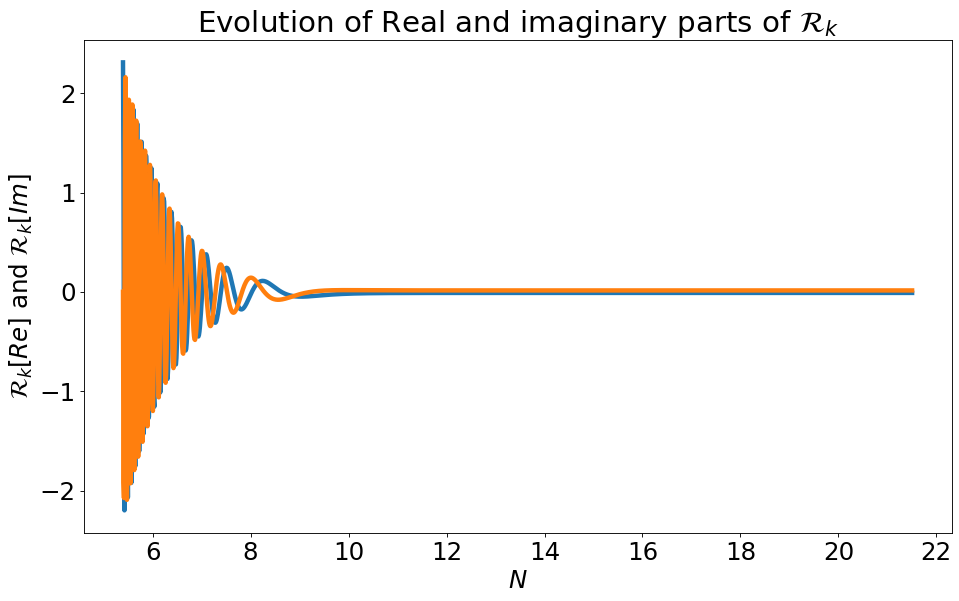

In [23]:
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'${\cal R}_k[Re]$ and ${\cal R}_k[Im]$')
plt.xlabel(r'$N$')
plt.title(r'Evolution of Real and imaginary parts of ${\cal R}_k$')
plt.plot(efolds_pert, soln_pert[:,2], lw=4)
plt.plot(efolds_pert, soln_pert[:,4], lw=4)
plt.show()

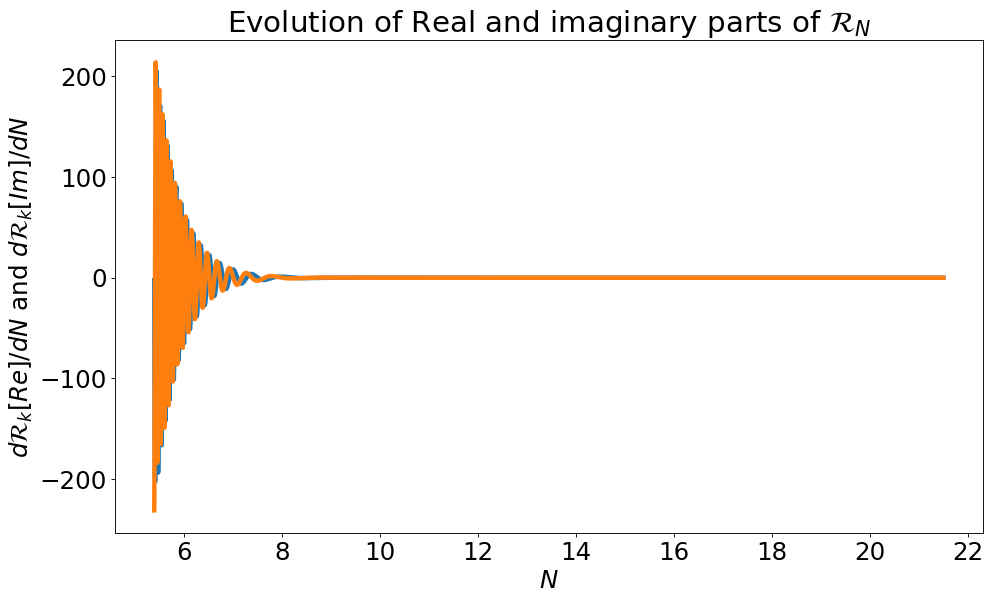

In [24]:
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'$d{\cal R}_k[Re]/dN$ and $d{\cal R}_k[Im]/dN$')
plt.xlabel(r'$N$')
plt.title(r'Evolution of Real and imaginary parts of ${\cal R}_N$')
plt.plot(efolds_pert, soln_pert[:,3], lw=4)
plt.plot(efolds_pert, soln_pert[:,5], lw=4)
plt.show()

In [25]:
def Psk(kk,Rk):
    Rk_re,Rk_Im=Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_Im*Rk_Im))

In [26]:
# Last element of R
Rk=[soln_pert[-1,2],soln_pert[-1,4]]

In [27]:
PPS_Scalar=Psk(k,Rk)
print('The primordial scalar power spectrum calculated at mode',k,'are:',PPS_Scalar)

The primordial scalar power spectrum calculated at mode 0.05 are: 2.049997614079006e-09


In [28]:
def computePPS(kk,atol=1e-8):
    idx_ic,Nic,Nshs=boundary(kk,efolds,ai*np.exp(efolds)*Hub,Nic_cond,Nshs_cond)
    efolds_pert=np.arange(Nic,Nshs,0.01)
    #print(kk,Nic,Nshs)
    pert_ic=initial_condition(idx_ic,kk)
    #print(kk,idx_ic,Nic,Nshs,pert_ic)
    sol_pert=integrate.odeint(pert_eqn,pert_ic,efolds_pert,args=(kk,),atol=atol)
    Rkshs=[sol_pert[-1,2],sol_pert[-1,4]]
    PSval=Psk(kk,Rkshs)
    return PSval

In [29]:
numK=500
karray=np.logspace(-4, 0, numK)
PS=np.zeros(numK)
#print(k)
kk=2
print('The primordial power spectrum calculated at mode',kk,'MPc^{-1} is:',computePPS(kk,1e-10))

The primordial power spectrum calculated at mode 2 MPc^{-1} is: 1.2699970057314406e-09


In [30]:
import time
pert_start_time=time.process_time()
for i in range(len(karray)):
    k=karray[i]
    PS[i]=computePPS(k)

pert_end_time=time.process_time()

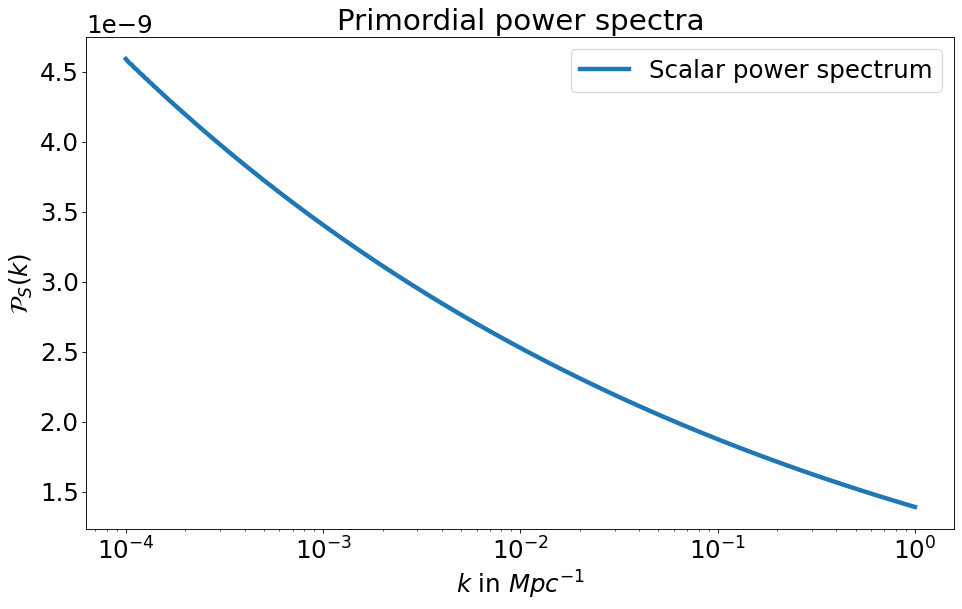

In [31]:
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'${\cal P}_{S}(k)$')
plt.xscale('log')
plt.xlabel(r'$k$ in $Mpc^{-1}$')
plt.title(r'Primordial power spectra')
plt.plot(karray,PS, lw=4,label='Scalar power spectrum')
plt.legend()
plt.show()

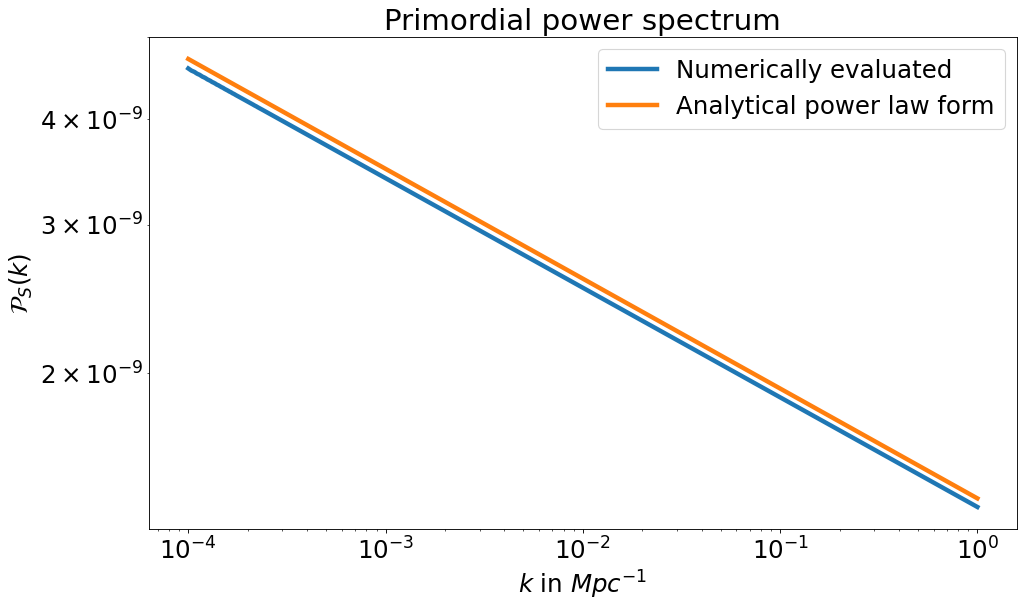

In [32]:
PSA=np.zeros(numK)
# Hilltop inflation with this (small) mu is strongly red-tilted; a local
# power-law fit near the pivot gives n_s ~ 0.87, well below the quadratic/
# quartic cases. This is a generic hilltop feature for sub-Planckian mu.
PSA=2.1e-9*(karray/0.05)**(0.87-1)
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'${\cal P}_S(k)$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ in $Mpc^{-1}$')
plt.title(r'Primordial power spectrum')
plt.plot(karray,PS, lw=4,label='Numerically evaluated')
plt.plot(karray,PSA, lw=4,label='Analytical power law form')
plt.legend()
plt.show()

## Tensor Perturbations, $n_s$, and $r$ (added)

This extends the notebook to also evolve the tensor-mode variables
(`hk_re`, `hk_im`), which `pert_eqn` already integrates alongside the
scalar `Rk_re`, `Rk_im` but which the original notebook never used. We now:

1. Extract the frozen tensor amplitude at super-horizon exit and compute the
   tensor power spectrum $\mathcal{P}_h(k) = 8\,\frac{k^3}{2\pi^2}(h_{k,\rm re}^2+h_{k,\rm im}^2)$
   (prefactor 8 = 2 polarizations $\times$ 4 from relating the code's
   canonically-normalized `hk` to the physical metric perturbation via
   $v_\lambda = (aM_{pl}/2)h_\lambda$; calibrated against the known
   slow-roll result $r=16\varepsilon_v$).
2. Compute $r(k) \equiv \mathcal{P}_h(k)/\mathcal{P}_\mathcal{R}(k)$ and report it at the pivot.
3. Fit $n_s$ numerically as the local log-slope of the already-computed
   scalar spectrum near the pivot.
4. Cross-check both against the analytic slow-roll formulas
   $n_s-1=-6\varepsilon_v+2\eta_v$, $r=16\varepsilon_v$, evaluated at the
   background field value 50 e-folds before the end of inflation (exactly
   where the pivot scale crosses the horizon, by construction of `ai`).

In [33]:
def Pth(kk, hk):
    """Tensor power spectrum from the frozen (h_re, h_im) at super-horizon exit."""
    hk_re, hk_im = hk
    return 8.0 * kk**3 / (2e0*np.pi**2) * ((hk_re*hk_re) + (hk_im*hk_im))

In [34]:
def computePPS_tensor(kk, atol=1e-8):
    """Like computePPS, but also returns the tensor power spectrum."""
    idx_ic, Nic, Nshs = boundary(kk, efolds, ai*np.exp(efolds)*Hub, Nic_cond, Nshs_cond)
    efolds_pert = np.arange(Nic, Nshs, 0.01)
    pert_ic = initial_condition(idx_ic, kk)
    sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert, args=(kk,), atol=atol)
    Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
    hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
    return Psk(kk, Rkshs), Pth(kk, hkshs)

In [35]:
PPS_pivot, PPT_pivot = computePPS_tensor(0.05, atol=1e-10)
r_pivot_numerical = PPT_pivot/PPS_pivot
print('Scalar power spectrum at pivot:', PPS_pivot)
print('Tensor power spectrum at pivot:', PPT_pivot)
print('Tensor-to-scalar ratio r at pivot (numerical):', r_pivot_numerical)

Scalar power spectrum at pivot: 2.049997916851393e-09
Tensor power spectrum at pivot: 1.1448223803956051e-12
Tensor-to-scalar ratio r at pivot (numerical): 0.0005584505091370759


In [36]:
# Full tensor spectrum over the same k-range already used for the scalar spectrum
PT = np.zeros(numK)
for i in range(len(karray)):
    _, PT[i] = computePPS_tensor(karray[i])
r_of_k = PT/PS

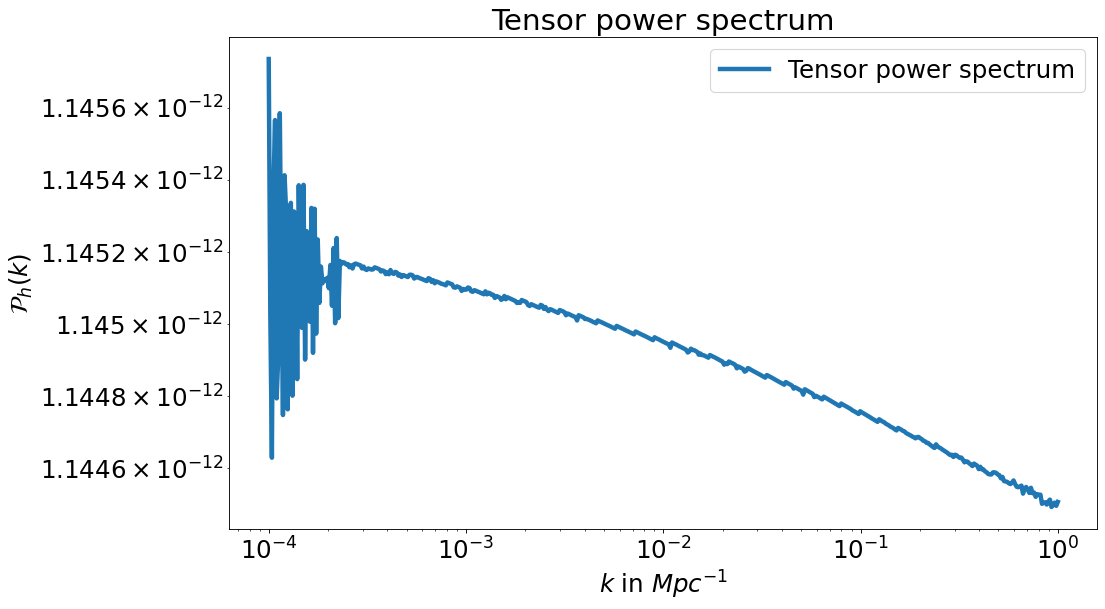

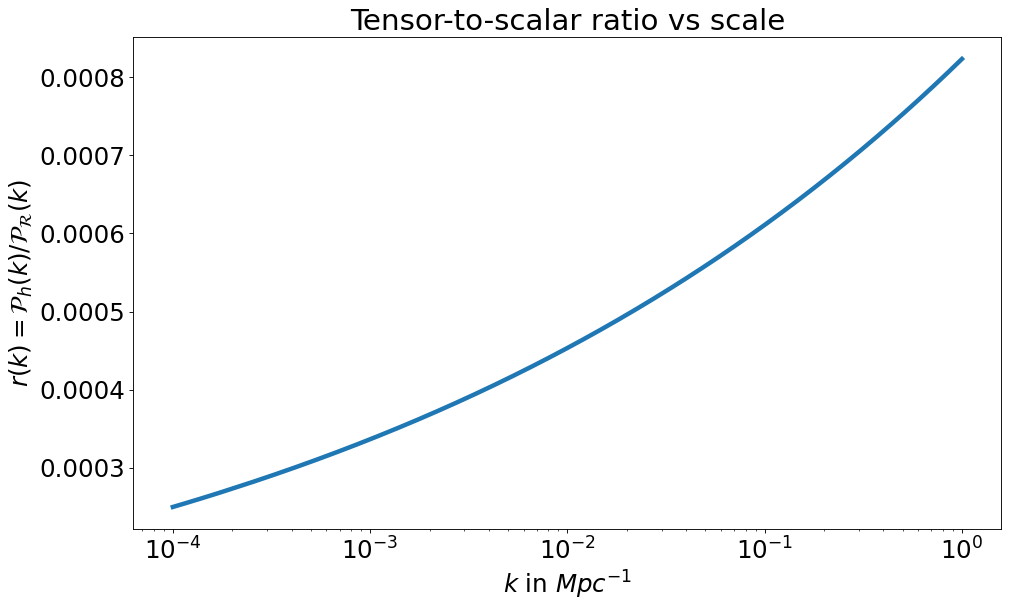

In [37]:
plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'${\cal P}_h(k)$')
plt.xscale('log'); plt.yscale('log')
plt.xlabel(r'$k$ in $Mpc^{-1}$')
plt.title(r'Tensor power spectrum')
plt.plot(karray, PT, lw=4, label='Tensor power spectrum')
plt.legend()
plt.show()

plt.figure(num=None, figsize=(14, 8), dpi=80, facecolor='w', edgecolor='k')
plt.ylabel(r'$r(k) = {\cal P}_h(k)/{\cal P}_{\cal R}(k)$')
plt.xscale('log')
plt.xlabel(r'$k$ in $Mpc^{-1}$')
plt.title(r'Tensor-to-scalar ratio vs scale')
plt.plot(karray, r_of_k, lw=4)
plt.show()

### Numerical $n_s$ (local log-slope fit) and slow-roll cross-check

In [38]:
mask = (karray > 0.02) & (karray < 0.125)
coef = np.polyfit(np.log(karray[mask]), np.log(PS[mask]), 1)
ns_numerical = 1 + coef[0]
print('Numerical n_s (local log-slope fit near pivot):', ns_numerical)
print('Numerical r at pivot:', r_pivot_numerical)

Numerical n_s (local log-slope fit near pivot): 0.8702779374226458
Numerical r at pivot: 0.0005584505091370759


In [39]:
def eps_eta_analytic(phi, mu=mu):
    # Hilltop V=V0*(1-(phi/mu)^2): work with the V0-independent shape v=1-(phi/mu)^2
    v = 1 - (phi/mu)**2
    dv = -2*phi/mu**2
    d2v = -2.0/mu**2
    eps = 0.5*(dv/v)**2
    eta = d2v/v
    return eps, eta

In [40]:
# Evaluate at the background field value 50 e-folds before the end of inflation --
# this is EXACTLY where the pivot mode crosses the horizon, by construction of ai.
phi_star = phi[Ne50_element]
eps_v, eta_v = eps_eta_analytic(phi_star)
ns_analytic = 1 - 6*eps_v + 2*eta_v
r_analytic = 16*eps_v
print('phi_* (horizon crossing, N_end-50):', phi_star)
print('eps_v, eta_v:', eps_v, eta_v)
print('Analytic (slow-roll) n_s:', ns_analytic)
print('Analytic (slow-roll) r:  ', r_analytic)
print()
print(f'Comparison -- n_s: numerical={ns_numerical:.4f}  analytic={ns_analytic:.4f}')
print(f'Comparison -- r:   numerical={r_pivot_numerical:.5f}  analytic={r_analytic:.5f}')

phi_* (horizon crossing, N_end-50): 0.13553365942635143
eps_v, eta_v: 4.019769764786343e-05 -0.06615587576685464
Analytic (slow-roll) n_s: 0.8674470622804036
Analytic (slow-roll) r:   0.0006431631623658149

Comparison -- n_s: numerical=0.8703  analytic=0.8674
Comparison -- r:   numerical=0.00056  analytic=0.00064
